# Session 2: Python basics through files and media

In this notebook you will find image files, load one, inspect its pixel array, handle two common errors, and transform an image. Run the cells in order. Write code only where a cell says **Your turn**.

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

Matplotlib is building the font cache; this may take a moment.


## Locate the supplied data

A relative path is interpreted from the notebook kernel's current working directory. The code below checks the few locations you are likely to use in this course. Read the output before continuing.

In [2]:
possible_data_dirs = [
    Path.cwd() / "shared_data" / "randalls_fish",
    Path.cwd().parent / "shared_data" / "randalls_fish",
    Path.cwd() / "Deliverables" / "prep" / "shared_data" / "randalls_fish",
]
data_dir = next((path for path in possible_data_dirs if path.exists()), None)
if data_dir is None:
    raise FileNotFoundError(f"Could not find the supplied data. Current directory: {Path.cwd()}")
print("Current directory:", Path.cwd())
print("Data directory:", data_dir)

Current directory: /Users/shirbar/Documents/CV4Ecology/2027/student prep/Deliverables/prep/02_files_and_media
Data directory: /Users/shirbar/Documents/CV4Ecology/2027/student prep/Deliverables/prep/shared_data/randalls_fish


## 1. Load and display one image (worked example)

This is the one complete example. It finds the first JPG, opens it safely, converts it to RGB, and displays it inline.

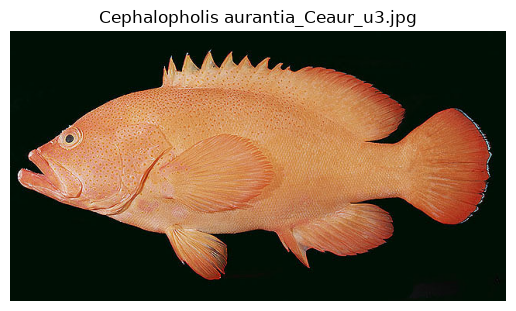

In [3]:
example_path = sorted(data_dir.glob("*.jpg"))[0]
with Image.open(example_path) as opened_image:
    example_image = opened_image.convert("RGB")

plt.imshow(example_image)
plt.title(example_path.name)
plt.axis("off");

## 2. Filter files by suffix

**Your turn:** `data_dir` contains both images and annotation files. Complete the list comprehension so it keeps only `.jpg`, `.jpeg`, and `.png` files. Use `path.suffix.lower()` so uppercase suffixes also work.

In [ ]:
media_suffixes = {".jpg", ".jpeg", ".png"}
all_paths = sorted(data_dir.iterdir())

image_paths = [
    # Replace this comment with the filtering expression.
]
if len(image_paths) == 0:
    print("Did you forget to complete the filtering expression for image_paths?")
else:
    print(f"Found {len(image_paths)} images among {len(all_paths)} files")
    print([path.name for path in image_paths[:3]])

Found 0 images among 20 files
[]


## 3. Understanding and inspecting how images are represented in Python

Before running the next cell, write down your answers:

- How many dimensions will the array have?
- What does each dimension represent?
- What will its data type be?
- What minimum and maximum values do you expect?

**Answers:** _Write your answer here._

In [5]:
example_array = np.asarray(example_image)
print("Shape:", example_array.shape)
print("Data type:", example_array.dtype)
print("Value range:", example_array.min(), "to", example_array.max())

Shape: (348, 640, 3)
Data type: uint8
Value range: 0 to 255


**Observation:** _Compare the result with your prediction. If the shape has three values, explain each one._

## 4. Write a reusable loader

**Your turn:** Complete `load_image`. It should accept a path, open the file with a `with` block, convert the image to RGB, convert it to a NumPy array, and return that array. Then test it with `image_paths[0]`.

In [ ]:
def load_image(path):
    # Write the function body here.
    pass

loaded_array = load_image(image_paths[0])
print(loaded_array.shape)

## 5. Follow a path from the working directory to the image

You successfully loaded `example_path`, but why does that path work? Python interprets every relative path as directions beginning at `Path.cwd()`. An **absolute path** (sometimes called a full path) instead begins at the filesystem root.

The cell below starts with the known working image. It expresses that same file both ways and then resolves the relative directions back to an absolute location. Read each printed path from left to right and notice which directory names the relative path must include.

In [7]:
absolute_path = example_path.resolve()
relative_path = Path(os.path.relpath(absolute_path, start=Path.cwd()))

print("Current working directory:", Path.cwd())
print("Relative path:           ", relative_path)
print("Absolute path:           ", absolute_path)
print("Relative path exists:    ", relative_path.exists())
print("Resolved relative path:  ", relative_path.resolve())
print("Both identify same file:", relative_path.resolve() == absolute_path)

Current working directory: /Users/shirbar/Documents/CV4Ecology/2027/student prep/Deliverables/prep/02_files_and_media
Relative path:            ../shared_data/randalls_fish/Cephalopholis aurantia_Ceaur_u3.jpg
Absolute path:            /Users/shirbar/Documents/CV4Ecology/2027/student prep/Deliverables/prep/shared_data/randalls_fish/Cephalopholis aurantia_Ceaur_u3.jpg
Relative path exists:     True
Resolved relative path:   /Users/shirbar/Documents/CV4Ecology/2027/student prep/Deliverables/prep/shared_data/randalls_fish/Cephalopholis aurantia_Ceaur_u3.jpg
Both identify same file: True


### Problematic paths

A filename shown in VS Code's file explorer can look as though it is available directly. In the next cell, the filename is correct, but the directory information has been dropped. `Path(example_path.name)` therefore tells Python to look for the image directly inside `Path.cwd()`; Python does not automatically search the rest of the project.

Before running the cell, compare `broken_path.resolve()` with `absolute_path` and explain why `load_image` will fail. Then repair **only** the `broken_path` assignment using either the correct relative path calculated above or `data_dir`.

**Why is this happening:** _Where will Python look, and where is the file actually stored?_

**After repairing it:** _Explain why your new path works from the current working directory._

In [8]:
broken_path = Path(example_path.name)
print("Python will look here:", broken_path.resolve())
print("The image is here:     ", absolute_path)
recovered_array = load_image(broken_path)
print("Loaded:", broken_path.name, recovered_array.shape)

Python will look here: /Users/shirbar/Documents/CV4Ecology/2027/student prep/Deliverables/prep/02_files_and_media/Cephalopholis aurantia_Ceaur_u3.jpg
The image is here:      /Users/shirbar/Documents/CV4Ecology/2027/student prep/Deliverables/prep/shared_data/randalls_fish/Cephalopholis aurantia_Ceaur_u3.jpg


NameError: name 'load_image' is not defined

## 6. Select an image safely

Task 5 checked whether a path points to a file that can be opened. This function checks a different problem: whether an index exists in the list. `raise` deliberately stops the function and reports a specific error instead of allowing the program to fail later with less context. Read the worked example, then run it with a valid index. Before trying index `100`, predict the exception type and message.

In [ ]:
def select_image(paths, index):
    if index < 0 or index >= len(paths):
        raise IndexError(
            f"Index {index} is invalid; there are {len(paths)} images."
        )
    return paths[index]

selected_path = select_image(image_paths, 1)
print("Selected:", selected_path.name)

# After writing your prediction, uncomment this line and inspect the error:
# select_image(image_paths, 100)

## 7. Implement and compare one transformation

**Your turn:** Choose exactly one Pillow operation: resize, center crop, grayscale, or horizontal flip. Apply it to `example_image`, assign the result to `transformed_image`, and run the comparison cell.

In [ ]:
# Example syntax to look up in Pillow: image.resize(...), image.crop(...),
# image.convert("L"), or Image.Transpose.FLIP_LEFT_RIGHT.
transformed_image = None  # Replace None with your transformation.

In [ ]:
if transformed_image is None:
    raise ValueError("Create transformed_image before running this cell")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(example_image)
axes[0].set_title(f"Original: {example_image.size}")
axes[1].imshow(transformed_image, cmap="gray" if transformed_image.mode == "L" else None)
axes[1].set_title(f"Transformed: {transformed_image.size}")
for ax in axes:
    ax.axis("off")
plt.tight_layout()

## Finish

Restart the kernel and run all cells in order. The intentional broken-path cell should fail until you replace its path; all other cells should finish without errors once your code is complete.